In [ ]:
import torch
import torch.nn as nn
import os
from deeplabv3.datasets import get_images, get_dataset, get_data_loaders
from deeplabv3.engine import train, validate
from deeplabv3.config import ALL_CLASSES, LABEL_COLORS_LIST
from deeplabv3.utils import save_model, SaveBestModel, save_plots, SaveBestModelIOU
from torch.optim.lr_scheduler import StepLR
from torchvision.models.segmentation import deeplabv3_resnet50
from deeplabv3.utils import get_segment_labels, draw_segmentation_map, image_overlay
from PIL import Image
import cv2
from deeplabv3.model import prepare_model
import matplotlib.pyplot as plt

Константы для обучения

In [ ]:
CHECKPOINT_PATH = "C:/PythonProjects/plant_disease_class/checkpoints/model_checkpoint.pth"
NUM_EPOCHS = 5
SEED = 42
LEARNING_RATE = 0.0001
ROOT_PATH = "C:/PythonProjects/plant_disease_class/leaf_segmentation/leaf_disease_segmentation/orig_data"
STEP_SIZE = 20
GAMMA = 0.1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Настройка GPU CUDA

In [4]:
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

Создаем модель на базе ResNet-50

In [ ]:
model = deeplabv3_resnet50(weights='DEFAULT')
model.classifier[4] = torch.nn.Conv2d(256, 2, 1)
model.aux_classifier[4] = torch.nn.Conv2d(256, 2, 1)

model = model.to(DEVICE)

Настройка директорий валидационной выборки

In [6]:
out_dir = os.path.join('.', 'outputs')
out_dir_valid_preds = os.path.join('.', 'outputs', 'valid_preds')
os.makedirs(out_dir, exist_ok=True)
os.makedirs(out_dir_valid_preds, exist_ok=True)

In [13]:
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.")

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

41,994,308 total parameters.
41,994,308 training parameters.


Получаем датасет, определяем переменные сохранения метрик оценки точности модели и функции самовызова

In [14]:
train_images, train_masks, valid_images, valid_masks = get_images(
    root_path = ROOT_PATH
)

classes_to_train = ALL_CLASSES

train_dataset, valid_dataset = get_dataset(
    train_images, 
    train_masks,
    valid_images,
    valid_masks,
    ALL_CLASSES,
    classes_to_train,
    LABEL_COLORS_LIST,
    img_size=512
)

train_dataloader, valid_dataloader = get_data_loaders(
    train_dataset, valid_dataset, batch_size=8
)

save_best_model = SaveBestModel()
save_best_iou = SaveBestModelIOU()

scheduler = StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

c:\PythonProjects\plant_disease_class\deeplabv3\datasets.py:42: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(img_size, img_size, always_apply=True),
c:\PythonProjects\plant_disease_class\deeplabv3\datasets.py:48: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=50, p=0.2),
c:\PythonProjects\plant_disease_class\deeplabv3\datasets.py:59: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(img_size, img_size, always_apply=True),
c:\PythonProjects\plant_disease_class\deeplabv3\datasets.py:27: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(


In [15]:
if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    epoch_start = ckpt['epoch']
else:
    epoch_start = 0

Обучаем модель

Epoch: 1
Training


|                    | 63/? [01:57<00:00,  1.86s/it]     


Validating


|                    | 12/? [00:04<00:00,  2.57it/s]     



Best validation loss: 0.3126937411725521

Saving best model for epoch: 1


Best validation IoU: 0.5934535360375649

Saving best model for epoch: 1

Train Epoch Loss: 0.4633, Train Epoch PixAcc: 0.8084, Train Epoch mIOU: 0.568664
Valid Epoch Loss: 0.3127, Valid Epoch PixAcc: 0.8243 Valid Epoch mIOU: 0.593454
--------------------------------------------------
Epoch: 2
Training


...


Best validation IoU: 0.6479968299116634

Saving best model for epoch: 4

Train Epoch Loss: 0.2368, Train Epoch PixAcc: 0.8921, Train Epoch mIOU: 0.688292
Valid Epoch Loss: 0.2251, Valid Epoch PixAcc: 0.8437 Valid Epoch mIOU: 0.647997
--------------------------------------------------
Epoch: 5
Training


|                    | 63/? [01:46<00:00,  1.70s/it]     


Validating


|                    | 12/? [00:04<00:00,  2.68it/s]     



Best validation loss: 0.19688154260317484

Saving best model for epoch: 5


Best validation IoU: 0.6646260901091486

Saving best model for epoch: 5

Train Epoch Loss: 0.2189, Train Epoch PixAcc: 0.8970, Train Epoch mIOU: 0.701957
Valid Epoch Loss: 0.1969, Valid Epoch PixAcc: 0.8488 Valid Epoch mIOU: 0.664626
--------------------------------------------------
Training finished.


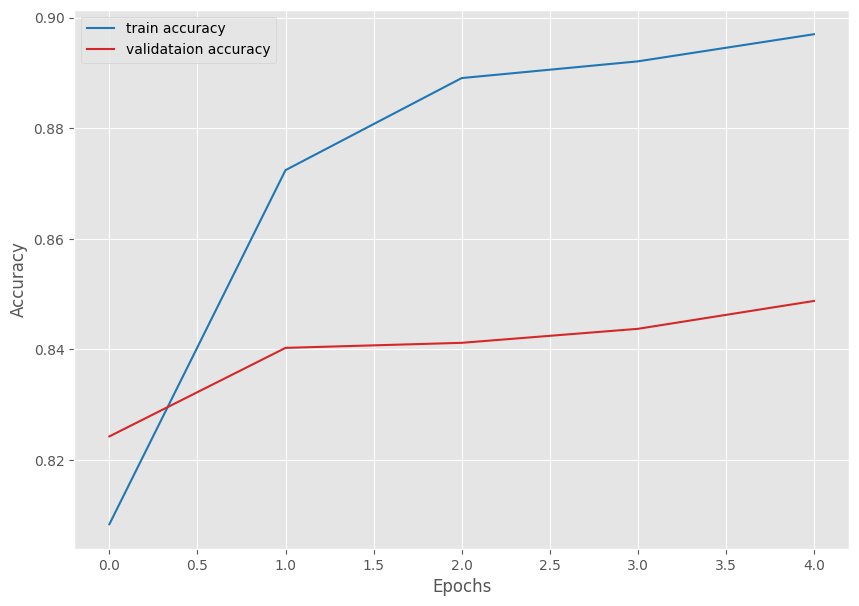

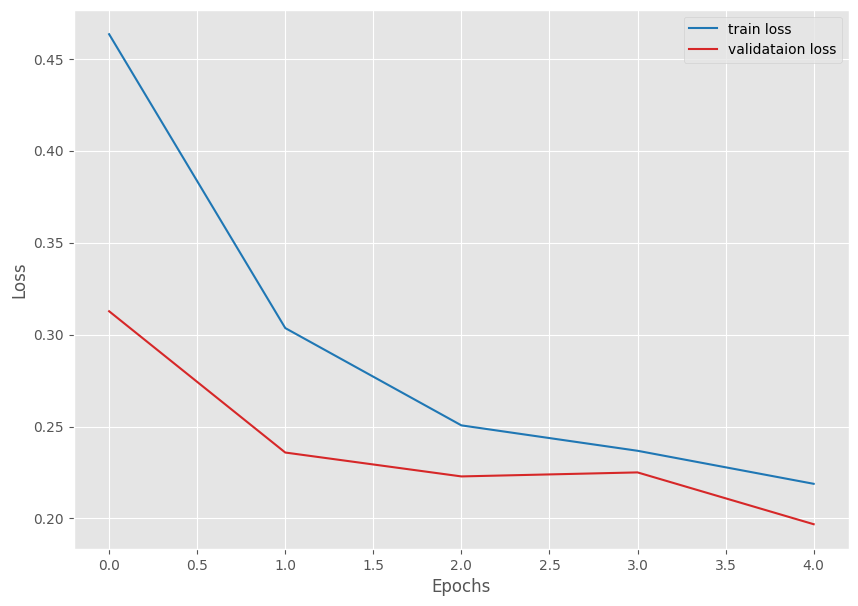

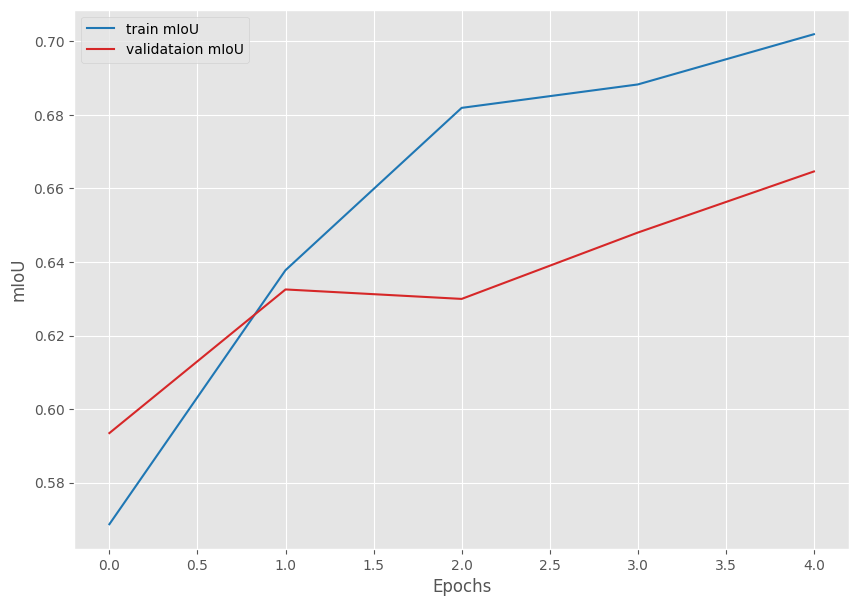

In [ ]:
train_loss, train_pix_acc, train_miou = [], [], []
valid_loss, valid_pix_acc, valid_miou = [], [], []

for epoch in range (epoch_start, NUM_EPOCHS):
    print(f"Epoch: {epoch + 1}")
    train_epoch_loss, train_epoch_pixacc, train_epoch_miou = train(
        model,
        train_dataset,
        train_dataloader,
        DEVICE,
        optimizer,
        criterion,
        classes_to_train
    )
    valid_epoch_loss, valid_epoch_pixacc, valid_epoch_miou = validate(
        model,
        valid_dataset,
        valid_dataloader,
        DEVICE,
        criterion,
        classes_to_train,
        LABEL_COLORS_LIST,
        epoch,
        ALL_CLASSES,
        save_dir=out_dir_valid_preds
    )
    train_loss.append(train_epoch_loss)
    train_pix_acc.append(train_epoch_pixacc)
    train_miou.append(train_epoch_miou)
    valid_loss.append(valid_epoch_loss)
    valid_pix_acc.append(valid_epoch_pixacc)
    valid_miou.append(valid_epoch_miou)

    save_best_model(
        valid_epoch_loss, epoch, model, out_dir, name='model_loss'
    )
    save_best_iou(
        valid_epoch_miou, epoch, model, out_dir, name='model_iou'
    )

    print(
        f"Train Epoch Loss: {train_epoch_loss:.4f},",
        f"Train Epoch PixAcc: {train_epoch_pixacc:.4f},",
        f"Train Epoch mIOU: {train_epoch_miou:4f}"
    )
    print(
        f"Valid Epoch Loss: {valid_epoch_loss:.4f},", 
        f"Valid Epoch PixAcc: {valid_epoch_pixacc:.4f}",
        f"Valid Epoch mIOU: {valid_epoch_miou:4f}"
    )
    scheduler.step()
    print('-' * 50)

save_model(NUM_EPOCHS, model, optimizer, criterion, out_dir, name='model')

save_plots(
    train_pix_acc, valid_pix_acc, 
    train_loss, valid_loss,
    train_miou, valid_miou, 
    out_dir
)
print('Training finished.')

In [ ]:
out_dir = os.path.join('.', 'outputs', 'inference_results')
os.makedirs(out_dir, exist_ok=True)

model = prepare_model(num_classes=len(ALL_CLASSES)).to(DEVICE)

torch.serialization.add_safe_globals([torch.nn.modules.loss.CrossEntropyLoss])

ckpt = torch.load('outputs/model.pth', weights_only=True)
model.load_state_dict(ckpt['model_state_dict'])
model.eval().to(DEVICE)

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

Тестируем на изображении

In [ ]:
# image_path = "C:/PythonProjects/plant_disease_class/leaf_segmentation/leaf_disease_segmentation/orig_data/valid_images"
image_path = "C:/PythonProjects/plant_disease_class"
images = os.listdir(image_path)
# image_name = "00224.jpg"
image_name = "Tomato___Early_blight1.JPG"

image = Image.open(os.path.join(image_path, image_name))

image = image.resize((512, 512))

outputs = get_segment_labels(image, model, DEVICE)
outputs = outputs['out']
segmented_image = draw_segmentation_map(outputs)
final_image = cv2.cvtColor(image_overlay(image, segmented_image), cv2.COLOR_BGR2RGB)

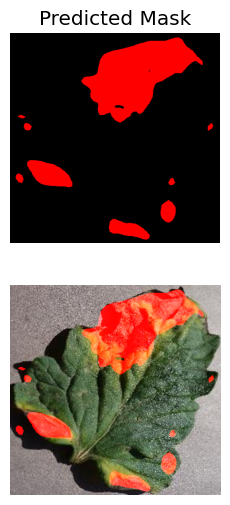

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.title('Predicted Mask')
plt.imshow(segmented_image)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(final_image)
plt.axis('off')

plt.show()

Сохраняем в .onnx

In [ ]:
onnx_filename = os.path.join(out_dir, 'deeplabv3_resnet50.onnx')

model.eval()

dummy_input = torch.randn(1, 3, 512, 512).to(DEVICE)
torch.onnx.export(
    model,
    dummy_input,
    onnx_filename,
    export_params=True,
    opset_version=12,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

print(f"Model saved to {onnx_filename}")

Model saved to .\outputs\inference_results\deeplabv3_resnet50.onnx
